In [1]:
import numpy as np
import pandas as pd
import torch

In [2]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
import os, kagglehub, shutil

path = '/content/tomato_dataset'

if not os.path.exists(path):
    raw = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
    src = f"{raw}/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

    for split in ['train', 'valid']:
      for folder in os.listdir(f"{src}/{split}"):
        if folder.startswith("Tomato___"):
          shutil.copytree(f"{src}/{split}/{folder}", f"{path}/{split}/{folder}", dirs_exist_ok=True)

    src_test = f"{raw}/test/test"
    dst_test = f"{path}/test"

    os.makedirs(dst_test, exist_ok=True)
    for file in os.listdir(src_test):
      if "Tomato" in file:
        shutil.copy(os.path.join(src_test, file), os.path.join(dst_test, file))

    print("Tomato Dataset Succesfully Downloaded")
else:
  print("Tomato Dataset Already Downloaded")

Tomato Dataset Already Downloaded


In [4]:
for split in ['train', 'valid']:
  split_path = os.path.join(path, split)
  print(f"{split} : {len(os.listdir(split_path))}")
  for folder in os.listdir(split_path):
    print(f"{folder} : {len(os.listdir(os.path.join(split_path, folder)))}")

train : 10
Tomato___Late_blight : 1851
Tomato___Bacterial_spot : 1702
Tomato___Target_Spot : 1827
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 1961
Tomato___Spider_mites Two-spotted_spider_mite : 1741
Tomato___Tomato_mosaic_virus : 1790
Tomato___Early_blight : 1920
Tomato___healthy : 1926
Tomato___Septoria_leaf_spot : 1745
Tomato___Leaf_Mold : 1882
valid : 10
Tomato___Late_blight : 463
Tomato___Bacterial_spot : 425
Tomato___Target_Spot : 457
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 490
Tomato___Spider_mites Two-spotted_spider_mite : 435
Tomato___Tomato_mosaic_virus : 448
Tomato___Early_blight : 480
Tomato___healthy : 481
Tomato___Septoria_leaf_spot : 436
Tomato___Leaf_Mold : 470


In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(os.path.join(path, 'train'), transform=train_transform)
valid_dataset = datasets.ImageFolder(os.path.join(path, 'valid'), transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
  )
valid_loader = DataLoader(
    valid_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
  )

print(f"Train : {len(train_dataset)}")
print(f"Valid : {len(valid_dataset)}")

Train : 18345
Valid : 4585


In [6]:
print(train_dataset.classes)

['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [7]:
image, label = train_dataset[0]
print(image.shape, label)

torch.Size([3, 224, 224]) 0


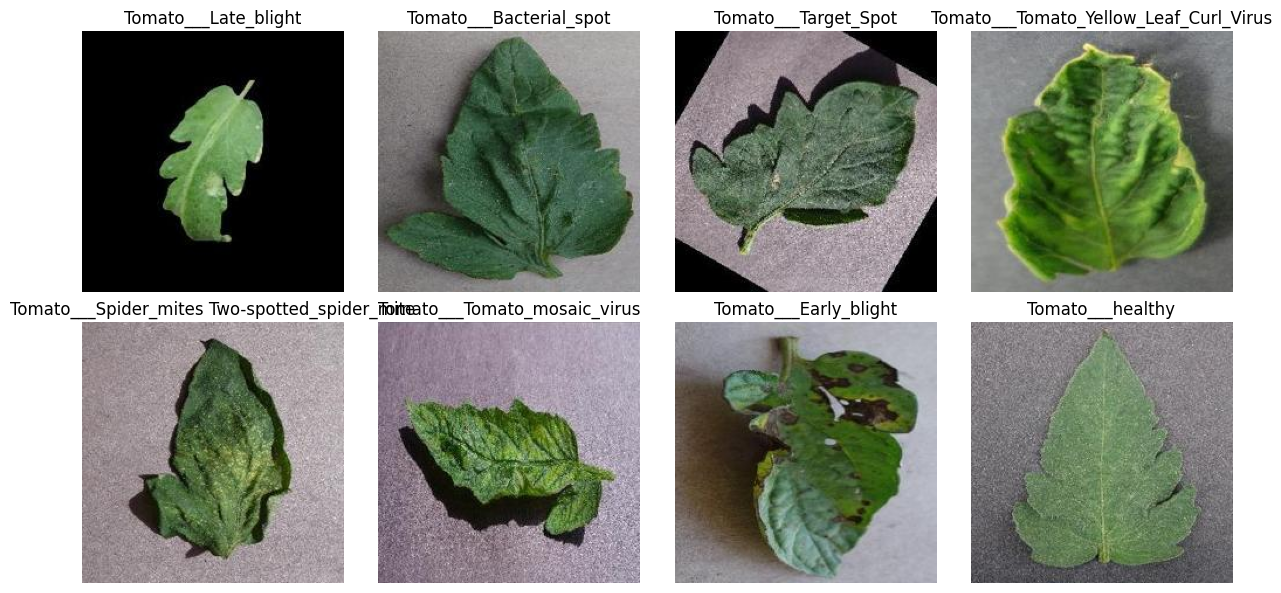

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import os

train_dir = os.path.join(path, 'train')
classes = os.listdir(train_dir)[:8]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, class_name in enumerate(classes):
    class_dir = os.path.join(train_dir, class_name)
    sample_filename = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, sample_filename)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [9]:
import os
from torch.utils.data import Dataset
from PIL import Image

filename_to_class = {
    'BacterialSpot': 'Tomato___Bacterial_spot',
    'EarlyBlight': 'Tomato___Early_blight',
    'LateBlight': 'Tomato___Late_blight',
    'LeafMold': 'Tomato___Leaf_Mold',
    'SeptoriaLeafSpot': 'Tomato___Septoria_leaf_spot',
    'SpiderMites': 'Tomato___Spider_mites Two-spotted_spider_mite',
    'TargetSpot': 'Tomato___Target_Spot',
    'YellowCurlVirus': 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'MosaicVirus': 'Tomato___Tomato_mosaic_virus',
    'Healthy': 'Tomato___healthy'
}

class TomatoTestDataset(Dataset):
  def __init__(self, root_dir, transform=None):
    self.root_dir = root_dir
    self.transform = transform
    self.images = [
        f for f in os.listdir(root_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    img_name = self.images[idx]
    img_path = os.path.join(self.root_dir, img_name)
    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image)

    class_name = None
    for key, name in filename_to_class.items():
        if key.lower() in img_name.lower():
            class_name = name
            break

    label = train_dataset.class_to_idx[class_name] if class_name else -1

    return image, label, img_name

In [10]:
test_dataset = TomatoTestDataset(os.path.join(path, 'test'), transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [11]:
sample_img, sample_lbl, img_name = test_dataset[3]
print(f"Sample Image Shape: {sample_img.shape}")
print(f"Sample Label Index: {sample_lbl} ({train_dataset.classes[sample_lbl]})")
print(f"Image name: {img_name}")

Sample Image Shape: torch.Size([3, 224, 224])
Sample Label Index: 7 (Tomato___Tomato_Yellow_Leaf_Curl_Virus)
Image name: TomatoYellowCurlVirus5.JPG


In [12]:
import torch.nn as nn

class Model(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.AdaptiveAvgPool2d((4, 4))
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=128*4*4, out_features=512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(in_features=512, out_features=num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [13]:
epochs=20
learning_rate=0.001

In [14]:
model = Model(num_classes=len(train_dataset.classes))
model.to(device)

criteration = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [15]:
len(train_loader)

144

In [16]:
class EarlyStopping:
  def __init__(self, patience=3, min_delta=0, verbose=False):
    self.patience = patience
    self.min_delta = min_delta
    self.verbose = verbose
    self.counter = 0
    self.best_loss = None
    self.early_stop = False

  def __call__(self, val_loss):
    if self.best_loss is None or self.best_loss - val_loss > self.min_delta:
      self.best_loss = val_loss
      self.counter = 0
    else:
      self.counter += 1
      if self.counter >= self.patience:
        self.early_stop = True
    return self.early_stop


In [17]:
patience = 5
min_delta = 0.001

early_stopping = EarlyStopping(patience=patience, min_delta=min_delta, verbose=True)

In [18]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
  val_loss = 0.0
  train_loss = 0.0

  train_correct = 0
  train_total = 0

  val_correct = 0
  val_count = 0

  model.train()

  for images, labels in train_loader:
    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criteration(outputs, labels)
    loss.backward()
    optimizer.step()

    train_loss += loss.item() * images.size(0)
    train_total += images.size(0)
    _, predicted = torch.max(outputs.data, 1)
    train_correct += (predicted == labels).sum().item()


  # validation
  model.eval()

  with torch.no_grad():
    for images, labels in valid_loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      loss = criteration(outputs, labels)

      val_loss += loss.item() * images.size(0)
      val_count += images.size(0)
      _, predicted = torch.max(outputs.data, 1)
      val_correct += (predicted == labels).sum().item()

  train_loss = train_loss / train_total
  train_accuracy = train_correct / train_total
  val_accuracy = val_correct / val_count
  val_loss = val_loss / val_count

  train_losses.append(train_loss)
  train_accuracies.append(train_accuracy)
  val_losses.append(val_loss)
  val_accuracies.append(val_accuracy)

  print(f"Epoch: {epoch+1}/{epochs}")
  print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
  print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}")

  if early_stopping(val_loss):
    print("Early Stopping")
    break

Epoch: 1/20
Train Loss: 0.8318 | Train Accuracy: 0.7031
Val Loss: 0.3779 | Val Accuracy: 0.8766
Epoch: 2/20
Train Loss: 0.4114 | Train Accuracy: 0.8601
Val Loss: 0.3626 | Val Accuracy: 0.8720
Epoch: 3/20
Train Loss: 0.3251 | Train Accuracy: 0.8885
Val Loss: 0.2380 | Val Accuracy: 0.9182
Epoch: 4/20
Train Loss: 0.2661 | Train Accuracy: 0.9080
Val Loss: 0.1777 | Val Accuracy: 0.9359
Epoch: 5/20
Train Loss: 0.2207 | Train Accuracy: 0.9242
Val Loss: 0.1725 | Val Accuracy: 0.9391
Epoch: 6/20
Train Loss: 0.1952 | Train Accuracy: 0.9332
Val Loss: 0.2130 | Val Accuracy: 0.9269
Epoch: 7/20
Train Loss: 0.1797 | Train Accuracy: 0.9366
Val Loss: 0.1241 | Val Accuracy: 0.9601
Epoch: 8/20
Train Loss: 0.1621 | Train Accuracy: 0.9431
Val Loss: 0.1359 | Val Accuracy: 0.9533
Epoch: 9/20
Train Loss: 0.1464 | Train Accuracy: 0.9490
Val Loss: 0.1147 | Val Accuracy: 0.9601
Epoch: 10/20
Train Loss: 0.1428 | Train Accuracy: 0.9497
Val Loss: 0.1129 | Val Accuracy: 0.9618
Epoch: 11/20
Train Loss: 0.1337 | Train

In [19]:
import matplotlib.pyplot as plt

def plot_graph(train_losses, val_losses, train_accuracies, val_accuracies):
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(train_accuracies, label='Train Accuracy')
  plt.plot(val_accuracies, label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.tight_layout()
  plt.show()

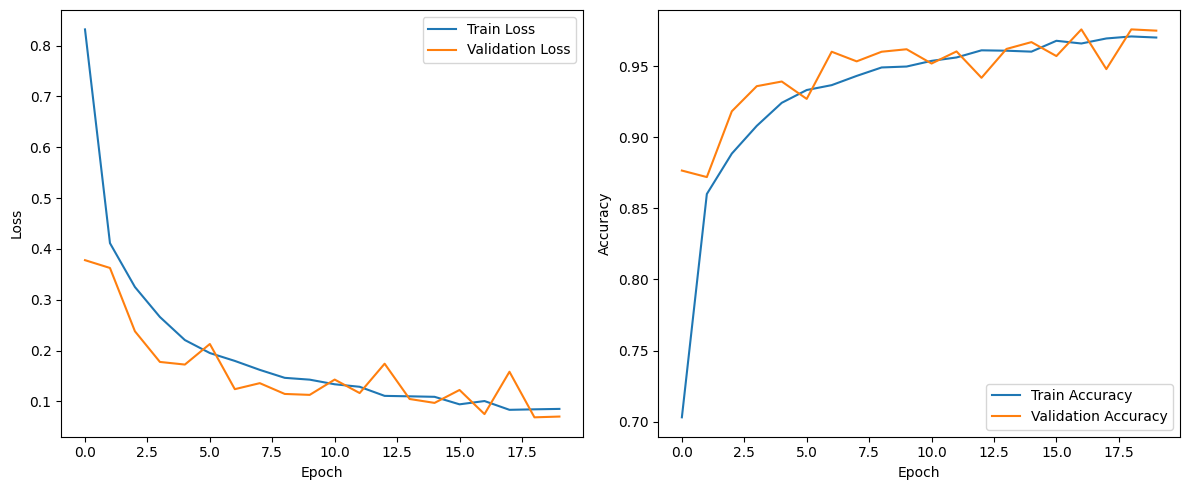

In [20]:
plot_graph(train_losses, val_losses, train_accuracies, val_accuracies)

In [23]:
model.eval()
correct_test = 0
total_test = 0
test_loss = 0.0

with torch.no_grad():
  for images, labels, img_names in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    loss = criteration(outputs, labels)

    test_loss += loss.item() * images.size(0)
    _, predicted = torch.max(outputs.data, 1)
    total_test += labels.size(0)
    correct_test += (predicted == labels).sum().item()

avg_test_loss = test_loss / total_test
test_accuracy = correct_test / total_test

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.3180
Test Accuracy: 0.8750


In [22]:
for images, labels, img_names in test_loader:
    print("images shape:", images.shape)
    print("labels type/shape:", type(labels), getattr(labels, 'shape', len(labels)))
    print("labels sample:", labels)
    print("img_names:", img_names)
    break

images shape: torch.Size([16, 3, 224, 224])
labels type/shape: <class 'torch.Tensor'> torch.Size([16])
labels sample: tensor([1, 7, 1, 7, 7, 7, 9, 7, 9, 7, 1, 9, 1, 9, 1, 1])
img_names: ('TomatoEarlyBlight5.JPG', 'TomatoYellowCurlVirus6.JPG', 'TomatoEarlyBlight3.JPG', 'TomatoYellowCurlVirus5.JPG', 'TomatoYellowCurlVirus3.JPG', 'TomatoYellowCurlVirus2.JPG', 'TomatoHealthy1.JPG', 'TomatoYellowCurlVirus4.JPG', 'TomatoHealthy2.JPG', 'TomatoYellowCurlVirus1.JPG', 'TomatoEarlyBlight1.JPG', 'TomatoHealthy4.JPG', 'TomatoEarlyBlight4.JPG', 'TomatoHealthy3.JPG', 'TomatoEarlyBlight6.JPG', 'TomatoEarlyBlight2.JPG')


In [24]:
torch.save(model.state_dict(), 'tomato_model.pth')

#Transfer Learning

In [25]:
import torchvision.models as models
import torch.nn as nn

In [26]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for params in model.parameters():
  params.requires_grad = False;

num_fits = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_fits, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, len(train_dataset.classes))
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


In [28]:
import torch.optim as optim
criteration = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

early_stopping = EarlyStopping(patience=3, min_delta=0.001, verbose=True)

epochs = 5

In [29]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
  train_loss = 0.0
  train_correct = 0
  train_total = 0

  val_loss = 0.0
  val_correct = 0
  val_total = 0

  model.train()
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criteration(outputs, labels)
    loss.backward()
    optimizer.step()

    train_loss += loss.item() * images.size(0)
    train_total += images.size(0)
    _, predicted = torch.max(outputs.data, 1)
    train_correct += (predicted == labels).sum().item()

  model.eval()
  with torch.no_grad():
    for images, labels in valid_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss =  criteration(outputs, labels)

      val_loss += loss.item() * images.size(0)
      val_total += images.size(0)
      _, predicted = torch.max(outputs.data, 1)
      val_correct += (predicted == labels).sum().item()

  train_loss = train_loss / train_total
  train_accuracy = train_correct / train_total
  val_accuracy = val_correct / val_total
  val_loss = val_loss / val_total

  train_losses.append(train_loss)
  train_accuracies.append(train_accuracy)
  val_losses.append(val_loss)
  val_accuracies.append(val_accuracy)

  print(f"Epoch [{epoch+1}/{epochs}]")
  print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
  print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_accuracy:.4f}\n")

  if early_stopping(val_loss):
    print("Early Stopping")
    break

Epoch [1/5]
Train Loss: 0.8428 | Train Acc: 0.7250
Val Loss:   0.4818 | Val Acc:   0.8441

Epoch [2/5]
Train Loss: 0.4572 | Train Acc: 0.8437
Val Loss:   0.3628 | Val Acc:   0.8829

Epoch [3/5]
Train Loss: 0.3883 | Train Acc: 0.8673
Val Loss:   0.3161 | Val Acc:   0.9003

Epoch [4/5]
Train Loss: 0.3470 | Train Acc: 0.8819
Val Loss:   0.2790 | Val Acc:   0.9051

Epoch [5/5]
Train Loss: 0.3122 | Train Acc: 0.8924
Val Loss:   0.2694 | Val Acc:   0.9101



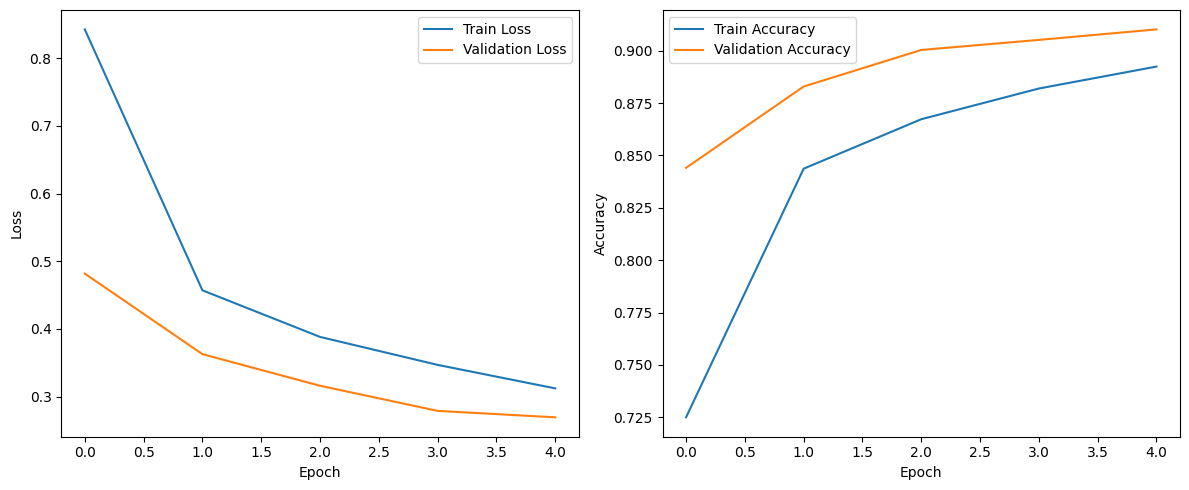

In [30]:
plot_graph(train_losses, val_losses, train_accuracies, val_accuracies)

In [31]:
model.eval()
correct_test = 0
total_test = 0
test_loss = 0.0

with torch.no_grad():
  for images, labels, _ in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    loss = criteration(outputs, labels)

    test_loss += loss.item() * images.size(0)
    _, predicted = torch.max(outputs.data, 1)
    total_test += labels.size(0)
    correct_test += (predicted == labels).sum().item()

avg_test_loss = test_loss / total_test
test_accuracy = correct_test / total_test

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2268
Test Accuracy: 0.8750
